# Create a dataset for EVASPA with landsat8 data 
* On a specific S2 tile ID
* On S2 tiles corresponding to a specific ROI

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../src")

In [3]:
import os
import geopandas as gpd
from tqdm import tqdm

In [4]:
from etdataset.grid import get_s2_tiles_from_roi
from etdataset.ls8 import create_dataset
from etdataset.plot import plot_images
from etdataset.common import write_dataset

### Prerequiste
For Level-1C and Level-2A, the granules, also called tiles, are 100x100 km2 ortho-images in UTM/WGS84 projection.
Tile grid can be download here: https://sentinel.esa.int/documents/247904/1955685/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml/ec05e22c-a2bc-4a13-9e84-02d5257b09a8  
Generate shapefile for S2 tiles with the following commands
```
ogr2ogr -f "ESRI Shapefile" -skipfailures -nlt polygon S2Atiles S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml 
ogr2ogr -f "ESRI Shapefile" -skipfailures -nlt polygon -nln S2Atiles S2Atiles S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml
```

### Inputs 
* Landsat product path
* S2 grid path
* S2 tile id or ROI path

In [5]:
if not os.environ.get("DATA_PATH"):
    raise Exception("DATA_PATH not defined")

In [6]:
data_path = os.environ["DATA_PATH"]

In [7]:
ls8_path = os.path.join(data_path,"Landsat8/LC09_L2SP_205050_20230327_20230329_02_T1/")
s2_tiles_path = os.path.join(data_path,"S2Atiles/S2Atiles.shp")
s2_tile_id = "28PCA"
roi_path = os.path.join(data_path,"zones/Zone_Senegal_Centre.shp") 

In [8]:
ls8_path

'/home/sarrazine/data/Landsat8/LC09_L2SP_205050_20230327_20230329_02_T1/'

In [9]:
roi_path

'/home/sarrazine/data/zones/Zone_Senegal_Centre.shp'

### Create dataset from Landsat8 product for a specific S2 tile ID

In [10]:
ls8 = create_dataset(ls8_path, s2_tile_id, s2_tiles_path)

(<Figure size 1500x1500 with 11 Axes>,
 array([[<Axes: title={'center': 'RGB'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LST'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Emissivity'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Albedo'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'NDVI'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LAI'}, xlabel='x', ylabel='y'>]],
       dtype=object))

/home/sarrazine/pyenvs/cesbio/lib/python3.10/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


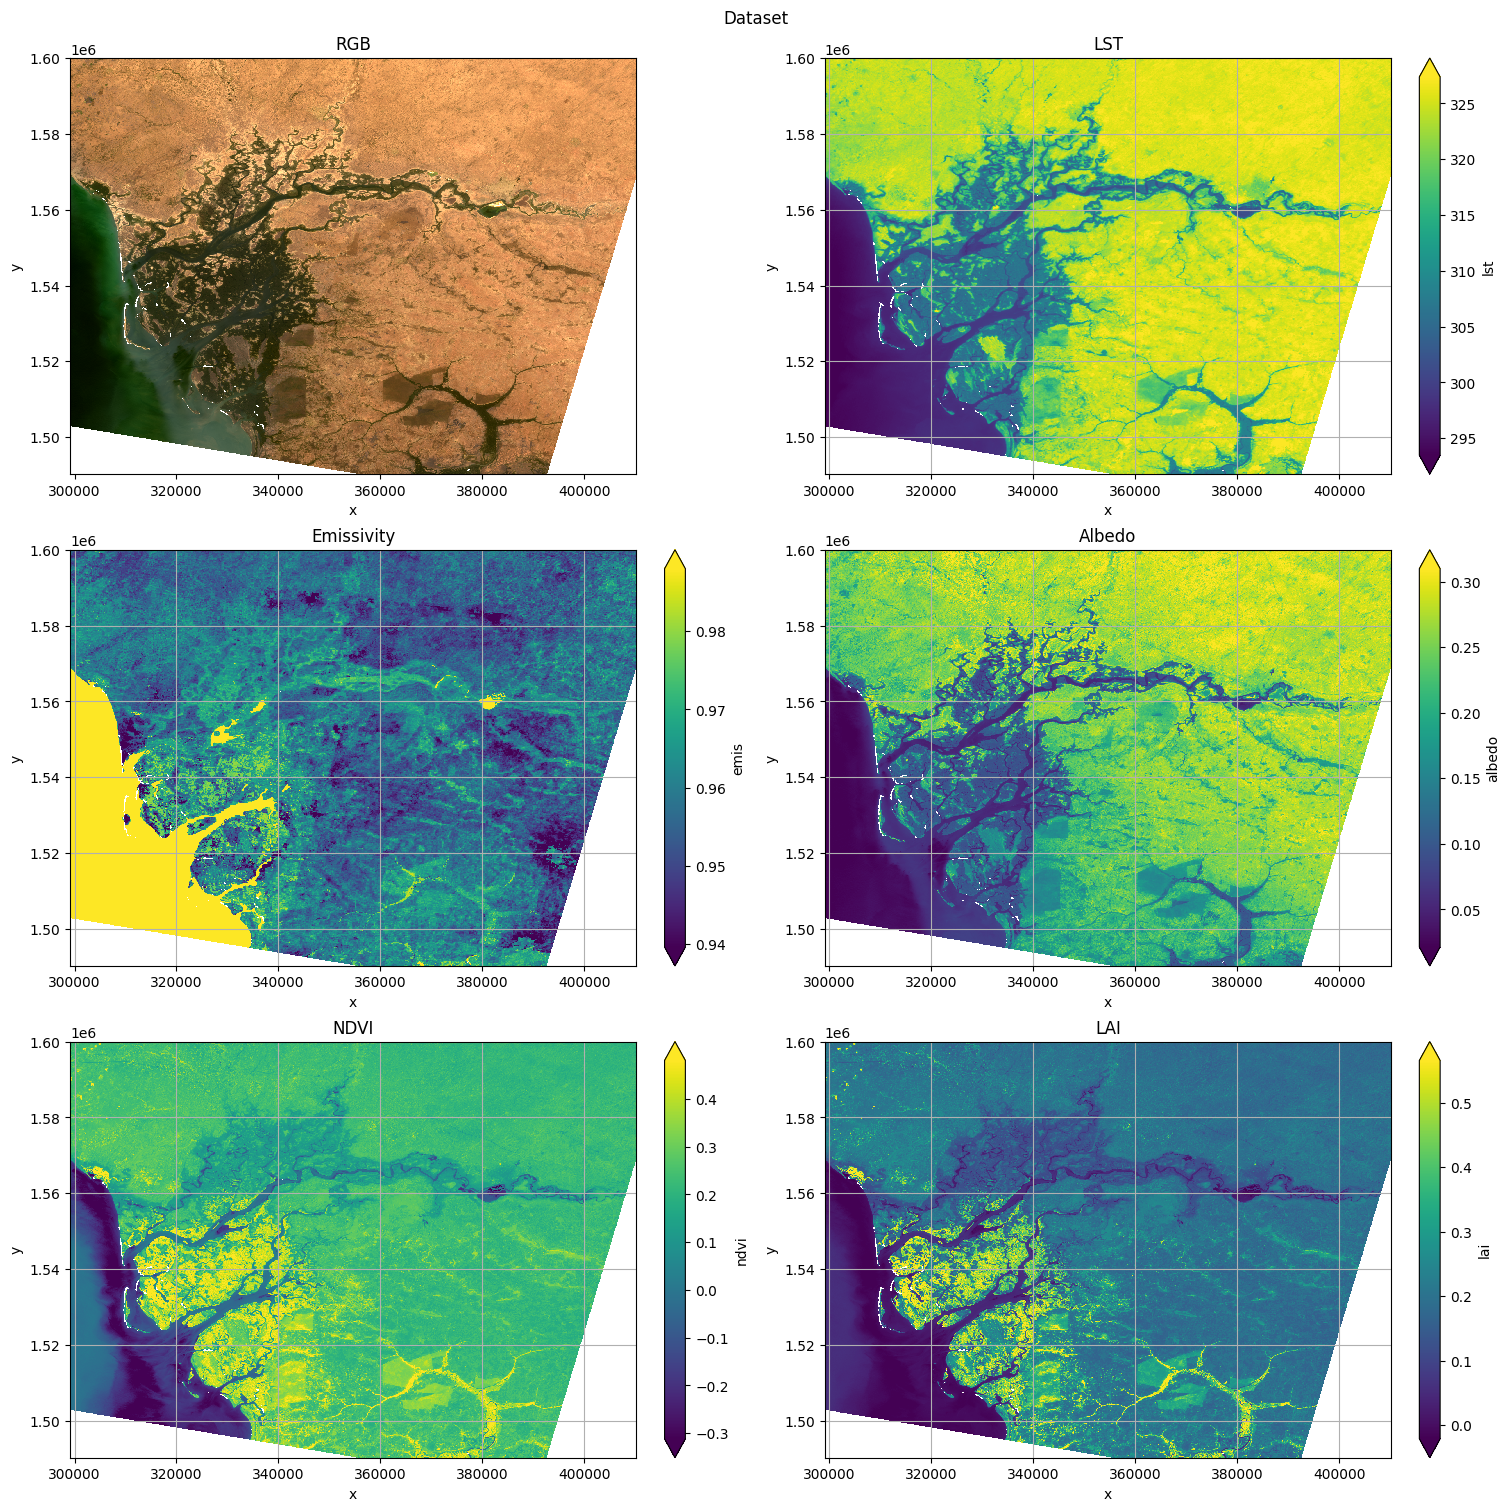

In [11]:
plot_images(ls8)

In [12]:
ls8.name

'Landsat'

### Create datasets from Landsat8 product for ROI

In [13]:
s2_grid = gpd.read_file(s2_tiles_path)

In [14]:
tile_ids = get_s2_tiles_from_roi(roi_path,s2_grid)
tile_ids 

['28PBA', '28PBB', '28PCA', '28PCB', '28PDA', '28PDB']

In [15]:
datasets = []
for tile_id in tqdm(tile_ids):
    ls8 = create_dataset(ls8_path, tile_id, s2_grid)
    datasets.append(ls8)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:30<00:00,  5.02s/it]


In [16]:
for ds in tqdm(datasets):
    write_dataset(ds)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00,  6.45it/s]
